# **Day 5**

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving House Price Prediction Dataset.csv to House Price Prediction Dataset (1).csv


In [ ]:
import numpy as np
import pandas as pd

df = pd.read_csv('House Price Prediction Dataset.csv')

In [ ]:
df.head()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Location,Condition,Garage,Price
0,1,1360,5,4,3,1970,Downtown,Excellent,No,149919
1,2,4272,5,4,3,1958,Downtown,Excellent,No,424998
2,3,3592,2,2,3,1938,Downtown,Good,No,266746
3,4,966,4,2,2,1902,Suburban,Fair,Yes,244020
4,5,4926,1,4,2,1975,Downtown,Fair,Yes,636056


In [ ]:
df.shape

(2000, 10)

In [ ]:
df.size

20000

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 10 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Id         2000 non-null   int64 
 1   Area       2000 non-null   int64 
 2   Bedrooms   2000 non-null   int64 
 3   Bathrooms  2000 non-null   int64 
 4   Floors     2000 non-null   int64 
 5   YearBuilt  2000 non-null   int64 
 6   Location   2000 non-null   object
 7   Condition  2000 non-null   object
 8   Garage     2000 non-null   object
 9   Price      2000 non-null   int64 
dtypes: int64(7), object(3)
memory usage: 156.4+ KB


In [ ]:
df.describe()

,Id,Area,Bedrooms,Bathrooms,Floors,YearBuilt,Price
count,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000,2000.000000,2000.000000
mean,1000.500000,2786.209500,3.003500,2.55250,1.993500,1961.446000,537676.855000
std,577.494589,1295.146799,1.424606,1.10899,0.809188,35.926695,276428.845719
min,1.000000,501.000000,1.000000,1.00000,1.000000,1900.000000,50005.000000
25%,500.750000,1653.000000,2.000000,2.00000,1.000000,1930.000000,300098.000000
50%,1000.500000,2833.000000,3.000000,3.00000,2.000000,1961.000000,539254.000000
75%,1500.250000,3887.500000,4.000000,4.00000,3.000000,1993.000000,780086.000000
max,2000.000000,4999.000000,5.000000,4.00000,3.000000,2023.000000,999656.000000


In [ ]:
df.dtypes

,0
Id,int64
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location,object
Condition,object
Garage,object
Price,int64


In [ ]:
df.isnull().sum()

,0
Id,0
Area,0
Bedrooms,0
Bathrooms,0
Floors,0
YearBuilt,0
Location,0
Condition,0
Garage,0
Price,0


In [ ]:
df.columns

Index(['Id', 'Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt',
       'Location', 'Condition', 'Garage', 'Price'],
      dtype='object')

In [ ]:
# to check the categorical values present in row

categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"Column '{col}': {df[col].unique()}")


Column 'Location': ['Downtown' 'Suburban' 'Urban' 'Rural']
Column 'Condition': ['Excellent' 'Good' 'Fair' 'Poor']
Column 'Garage': ['No' 'Yes']


In [ ]:
df['Condition'].unique()

array(['Excellent', 'Good', 'Fair', 'Poor'], dtype=object)

In [ ]:
df['Location'].unique()

array(['Downtown', 'Suburban', 'Urban', 'Rural'], dtype=object)

In [ ]:
df=df.drop(columns=['Id'],errors='ignore')

In [ ]:
# feature(x) and target(y) separation

x=df.drop(columns=['Price'])
y=df['Price']

In [ ]:
#train test split

# we can`t use stratify because the output values is in numerical

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print("Shape of X_train:", x_train.shape)
print("Shape of X_test:", x_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (1600, 8)
Shape of X_test: (400, 8)
Shape of y_train: (1600,)
Shape of y_test: (400,)


In [ ]:
x_train.dtypes

,0
Area,int64
Bedrooms,int64
Bathrooms,int64
Floors,int64
YearBuilt,int64
Location,object
Condition,object
Garage,object


Linear models and reguralization are sensitive to feature
Scalar so before regreession we encode categoricals and scale numericals

In [ ]:
categorical_cols = ['Location', 'Condition','Garage']
numerical_cols = x_train.drop(columns=categorical_cols).columns

In [ ]:
categorical_cols,numerical_cols

(['Location', 'Condition', 'Garage'],
 Index(['Area', 'Bedrooms', 'Bathrooms', 'Floors', 'YearBuilt'], dtype='object'))

In [ ]:
# Encoding
# we will use one hot encoder cuz regression needs number if increases feature

# ColumnTransformer is a class in scikit-learn that allows you to apply different preprocessing steps to different columns of your
# numerical_cols need scaling,categorical_cols need encoding so we should not treat all columns the same

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


# **Preprocesser**

In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(drop='first'), categorical_cols)
    ])

feature combination or concatenate we can`t use bec we alreadly  concatenate using ColumnTransformer

In [ ]:
# numerical_cols need scaling,categorical_cols need encoding
# fit_transform ==> train
# transform ==> test
x_train_processed = preprocessor.fit_transform(x_train)
x_test_processed = preprocessor.transform(x_test)

In [ ]:
x_train_processed.shape

(1600, 12)

In [ ]:
x_test_processed.shape

(400, 12)

### **Linear Regression: Explained**

In simple terms, Linear Regression is like finding the 'best-fit straight line' through a bunch of data points on a graph. Imagine you have data about houses, like their size and price. You plot these points, and Linear Regression helps you draw a straight line that comes closest to all those points. Once you have this line, you can use it to guess the price of a new house based on its size.

**Definition:** It's a method to model the relationship between a **dependent variable** (what you want to predict, e.g., 'Price') and one or more **independent variables** (the features that help predict, e.g., 'Area', 'Bedrooms'). It assumes this relationship can be represented by a straight line or a flat surface in higher dimensions.

### **How the Code Applies:**

Let's look at your code snippet:

```python
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(x_train_processed, y_train)
```

1.  **`from sklearn.linear_model import LinearRegression`**:
    *   This line is like getting a tool from your toolbox. You're importing the specific 'Linear Regression' tool from a machine learning library called `scikit-learn`.

2.  **`lr_model = LinearRegression()`**:
    *   Here, you're creating an empty 'Linear Regression machine'. It's ready to learn, but it doesn't know anything about houses or prices yet.

3.  **`lr_model.fit(x_train_processed, y_train)`**:
    *   This is the learning step! You feed your 'Linear Regression machine' the training data:
        *   `x_train_processed`: These are the 'features' of your training houses (like their processed area, number of bedrooms, etc.). They've been cleaned and standardized so the machine can understand them better.
        *   `y_train`: These are the *actual prices* for those training houses.
    *   The `fit()` method makes the machine analyze this data. It figures out the best possible straight line (or surface) that explains the relationship between the house features and their prices. After this step, your `lr_model` has 'learned' and is ready to make predictions on new, unseen houses.

In [ ]:
from sklearn.linear_model import LinearRegression
lr_model = LinearRegression()
lr_model.fit(x_train_processed, y_train)

LinearRegression()

In [ ]:
y_train_pred=lr_model.predict(x_train_processed)
y_test_pred=lr_model.predict(x_test_processed)

# predicting on both so
# train predition ==> check how well model learned
# test predition ==> check how well model generalize

# we predict on training data to see learning, in test to see the real world performance

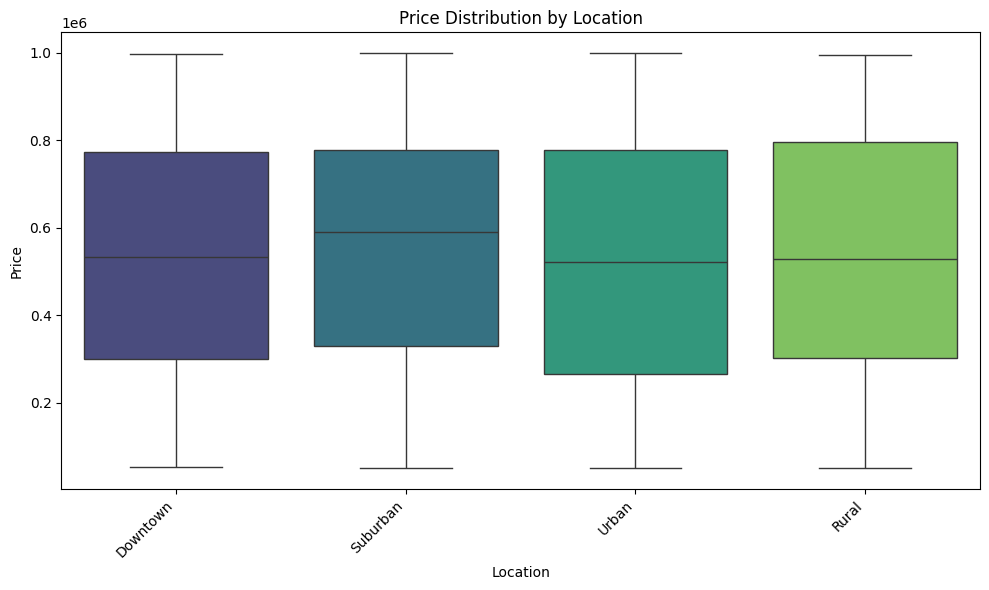

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Location', y='Price', hue='Location', palette='viridis', legend=False)
plt.title('Price Distribution by Location')
plt.xlabel('Location')
plt.ylabel('Price')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

# **Error and residual Interpretation**

### Error and Residual Interpretation: MAE, MSE, RMSE, R2

When we train a regression model (like the Linear Regression model here), we want to know how well it's predicting the actual values. We use various metrics to measure this 'goodness of fit' and understand the errors our model is making.

*   **MAE (Mean Absolute Error):**
    *   **Simple Idea:** This is like asking, "On average, how far off are our predictions from the actual values?"
    *   **What it tells you:** If your MAE is 200,000, it means your model's predictions are typically off by about $200,000, either too high or too low.
    *   **Units:** It's in the same units as your target variable (e.g., dollars for house prices).

*   **MSE (Mean Squared Error):**
    *   **Simple Idea:** This also measures how far off our predictions are, but it puts a much bigger penalty on large errors.
    *   **What it tells you:** Because it squares the errors, larger mistakes are heavily penalized. This makes it useful for showing if your model has a few really bad predictions. The value itself isn't easily interpretable in real-world units.
    *   **Units:** Squared units of your target variable.

*   **RMSE (Root Mean Squared Error):**
    *   **Simple Idea:** This is the square root of MSE. It brings the units back to the original scale of your data.
    *   **What it tells you:** Like MAE, it tells you the typical magnitude of the errors, but because it's derived from MSE, it's still more sensitive to large errors than MAE. If your RMSE is 250,000, your predictions are typically off by about $250,000.
    *   **Units:** Same units as your target variable (e.g., dollars).

*   **R2 Score (Coefficient of Determination):**
    *   **Simple Idea:** This is like asking, "How much of the variation in the actual prices can our model explain?"
    *   **What it tells you:**
        *   **1.0:** Your model perfectly explains all the variation in prices.
        *   **0.0:** Your model explains none of the variation; it's no better than simply predicting the average price for every house.
        *   **0.80:** Your model explains 80% of the variation in prices.
        *   **Less than 0:** This is a red flag! It means your model is performing worse than if you just predicted the average price for every house. It's telling you that your model is a very poor fit for the data.

In [ ]:
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

# the reason for using mae, mse, rmse, r2 is that we never judge a
# model by accuracy in LinearRegression
# here we used error based metrics

# y_test_pred = x_test_pred # Assigning the predictions to y_test_pred
# we need to use test model not train model

mae= mean_absolute_error(y_test,y_test_pred)
mse=mean_squared_error(y_test,y_test_pred)
rmse=np.sqrt(mse)
r2 = r2_score(y_test,y_test_pred)

print("MAE:",mae)
print("MSE:",mse)
print("RMSE:",rmse)
print("R2:",r2)

# MAE tells the avg absolute difference ble predicted and actual house prices
# we use this because its easy to understand same unit as prece,less sensitive
# to outliers( an outliner is a value that lies far away from yhe majority of values it the same col)

# MSE ==>its squares the errors, larger mistakes are heavily penalized.
# This makes it useful for showing if your model has a few really bad predictions.
# The value itself isn't easily interpretable in real-world units.

# RMSE ==> brings the units back to the original price unit, making it more interpretable, penalizes large errors.
# same unit comparing target_output

# r2-R2 ==> tells how much of the variation in the actual prices can our model explain.

MAE: 243241.97758826384
MSE: 78321466146.0328
RMSE: 279859.72583784326
R2: -0.006717808430749761


In [ ]:
# r2
# 0.0 -> model explains nothing
# 1.0 -> perfectmodel
# 0.80 -> model expalins 80% of the variance
# r2<0 -> model is worse than the mean

In [ ]:
train_r2=r2_score(y_train,y_train_pred)
test_r2=r2_score(y_test,y_test_pred)

print("Train R2:",train_r2)
print("Test R2:",test_r2)


Train R2: 0.009856184863687889
Test R2: -0.006717808430749761


# Regularization

In [ ]:
#ridge regression -- reduce the impect

from sklearn.linear_model import Ridge

ridge_model = Ridge(alpha=1.0)
ridge_model.fit(x_train_processed, y_train)

y_train_pred_ridge = ridge_model.predict(x_train_processed)
y_test_pred_ridge = ridge_model.predict(x_test_processed)

# ridge_model reduce the impact of less important frearture without removing them

In [ ]:
from sklearn.metrics import r2_score

train_r2_ridge = r2_score(y_train, y_train_pred_ridge)
test_r2_ridge = r2_score(y_test, y_test_pred_ridge)

print("Ridge Regression - Train R2:", train_r2_ridge)
print("Ridge Regression - Test R2:", test_r2_ridge)

Ridge Regression - Train R2: 0.009856156591055543
Ridge Regression - Test R2: -0.006715935063532852


In [ ]:
#lesso regression
# ridge reduce the impact of useless important frearture while lasso can completely
# eliminate useless fearture

from sklearn.linear_model import Lasso

lasso_model = Lasso(alpha=0.1, max_iter=10000)
lasso_model.fit(x_train_processed, y_train)

y_train_pred_lasso = lasso_model.predict(x_train_processed)
y_test_pred_lasso = lasso_model.predict(x_test_processed)

# ridge - shrinks coefficient
# lasso - shrinks coefficient to zero

In [ ]:
from sklearn.metrics import r2_score

train_r2_lasso = r2_score(y_train, y_train_pred_lasso)
test_r2_lasso = r2_score(y_test, y_test_pred_lasso)

print("Lasso Regression - Train R2:", train_r2_lasso)
print("Lasso Regression - Test R2:", test_r2_lasso)

Lasso Regression - Train R2: 0.009856184858633488
Lasso Regression - Test R2: -0.006717628013812593


In [ ]:
# underfitting properttting overfitting

# underfitting - linear regression -
# overfitting - decision tree



SyntaxError: invalid syntax (ipython-input-1351712272.py, line 1)

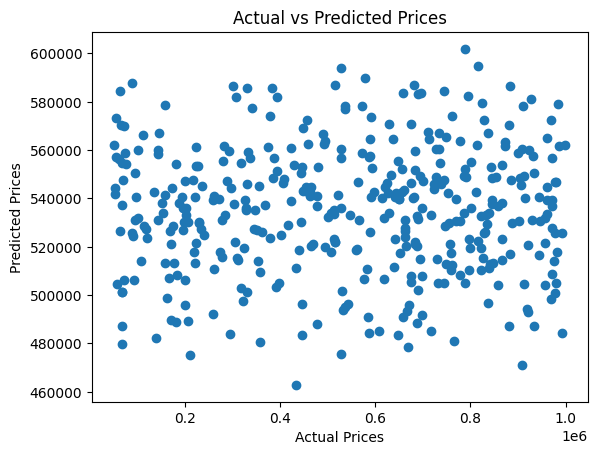

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_test,y_test_pred)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Prices")
plt.show()